# 생활인구 × 이송 건수 연관성 분석

**목적** : 생활인구가 이송 건수 예측 모델에 어떤 도움이 되는지 확인

**흐름**
- 데이터 불러오기 → 당월 생활인구 만들기 → 상관 분석(4가지 관점) → 인구 1만명당 이송률 → 시계열 분해 비교 → 시차 확인 → 예측 모델 비교 → 저장

**핵심 개념**
- 자치구 간 비교 : 구마다 평균을 내서 "큰 구가 이송도 많은가"를 보는 방법
- 자치구 내 비교 : 한 구 안에서 "인구가 늘어난 달에 이송도 늘었는가"를 보는 방법
- 두 비교가 다른 이유 : 구 규모 차이가 너무 커서 전체 상관이 규모에 끌려감

**사용 파일 (`ml_data` 폴더)**

| 파일 | 내용 |
|---|---|
| `transport_dataset.csv` | 자치구 × 월 이송 건수 + 전월 생활인구 |
| `population_dataset.csv` | 자치구 × 일 생활인구 (전일 값 포함) |

**결과 파일**

| 파일 | 위치 | 내용 |
|---|---|---|
| `relation_corr_table.csv` | ml_result | 인구 컬럼별 상관계수 (관점별) |
| `relation_district_rate.csv` | ml_result | 구별 인구 1만명당 이송률, 추세·계절·잔차 상관 |
| `relation_model_compare.csv` | ml_result | 특성 조합별 모델 성능 |
| `transport_pop_features.csv` | ml_data | 인구 기반 특성을 추가한 학습 데이터 |

## 0. 환경 설정
- 경로 : `BASE_DIR` 하나만 바꾸면 나머지 폴더가 따라 바뀜
- `TEST_START` : 이 날짜부터는 테스트용 (학습에 쓰지 않음)

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from scipy.stats import pearsonr, spearmanr
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings(action='ignore')

# 한글 폰트 자동 선택
font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR', 'Noto Sans CJK JP']
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in font_candidates if f in installed_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
else:
    print('[주의] 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

# 경로
BASE_DIR = Path(os.getenv('PROJECT_DIR', 'C:/ai/source/09_Project/cheolhyeon_jo'))
ML_DATA_DIR = BASE_DIR / 'ml_data'
RESULT_DIR = BASE_DIR / 'ml_result'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

TEST_START = '2025-01-01'

print('ML_DATA_DIR:', ML_DATA_DIR)
print('RESULT_DIR :', RESULT_DIR)

ML_DATA_DIR: C:\ai\source\09_Project\cheolhyeon_jo\ml_data
RESULT_DIR : C:\ai\source\09_Project\cheolhyeon_jo\ml_result


## 1. 데이터 불러오기
- `transport_dataset.csv` : 월별 이송 건수(`transport_cnt`)가 정답
- `population_dataset.csv` : 일별 생활인구
- 날짜 변환 : 문자열 → datetime (`parse_dates`)

In [2]:
transport = pd.read_csv(ML_DATA_DIR / 'transport_dataset.csv', parse_dates=['ds'])
population = pd.read_csv(ML_DATA_DIR / 'population_dataset.csv', parse_dates=['ds'])

print('이송 데이터 :', transport.shape, transport['ds'].min().date(), '~', transport['ds'].max().date())
print('인구 데이터 :', population.shape, population['ds'].min().date(), '~', population['ds'].max().date())
transport[['ds', 'District', '월', '전월_transport_cnt', '전월_night_pop', 'transport_cnt']].head()

이송 데이터 : (2564, 46) 2017-01-01 ~ 2025-12-01
인구 데이터 : (75825, 20) 2018-04-12 ~ 2026-07-31


,ds,District,월,전월_transport_cnt,전월_night_pop,transport_cnt
0,2017-01-01,강남구,1,NaN,NaN,1472.0
1,2017-02-01,강남구,2,1472.0,NaN,1255.0
2,2017-03-01,강남구,3,1255.0,NaN,1438.0
3,2017-04-01,강남구,4,1438.0,NaN,1512.0
4,2017-05-01,강남구,5,1512.0,NaN,1543.0


## 2. 당월 생활인구 만들기
- 필요한 이유 : 이송 데이터에는 **전월** 인구만 있음 → "같은 달" 관계를 보려면 당월 인구가 필요
- 방법 : `전일_` 컬럼을 하루 앞 날짜로 옮기면 그날의 실제 값
  - 예) 4월 12일 행의 `전일_total_pop` = 4월 11일 인구
- 월 단위 변환 : 일별 값 → 월평균 (`groupby` + `mean`)
- 병합 기준 : `ds`(월 첫날) + `District`

**인구 컬럼 뜻**
- `total_pop` : 총생활인구
- `day_pop` : 주간인구 (09~18시)
- `night_pop` : 야간인구 (19~08시), 거주 인구에 가까움
- `일최대인구수` / `일최소인구수` : 하루 중 가장 많을 때 / 적을 때
- `서울외유입인구수` : 서울 밖에서 들어온 인구
- `pop_diff` : 주간 - 야간 인구 차이

In [3]:
prev_cols = [c for c in population.columns if c.startswith('전일_')]

daily = population[['ds', 'District'] + prev_cols].copy()
daily['ds'] = daily['ds'] - pd.Timedelta(days=1)                 # 하루 앞으로 이동
daily.columns = ['ds', 'District'] + [c.replace('전일_', '') for c in prev_cols]
POP_COLS = daily.columns[2:].tolist()

daily['ds'] = daily['ds'].dt.to_period('M').dt.to_timestamp()   # 날짜 → 그 달 1일
pop_month = daily.groupby(['ds', 'District'], as_index=False)[POP_COLS].mean()

df = transport[['ds', 'District', '월', 'transport_cnt']].merge(pop_month, on=['ds', 'District'], how='inner')
df = df.sort_values(['District', 'ds']).reset_index(drop=True)

print('인구 컬럼 :', POP_COLS)
print('병합 결과 :', df.shape, df['ds'].min().date(), '~', df['ds'].max().date())
print('자치구 수 :', df['District'].nunique())
df.head()

인구 컬럼 : ['total_pop', '내국인생활인구수', '장기체류외국인인구수', '단기체류외국인인구수', '일최대인구수', '일최소인구수', 'day_pop', 'night_pop', '일최대이동인구수', '서울외유입인구수', '동일자치구행정동간이동인구수', '자치구간이동인구수', 'pop_diff']
병합 결과 : (2233, 17) 2018-04-01 ~ 2025-12-01
자치구 수 : 25


,ds,District,월,transport_cnt,total_pop,내국인생활인구수,장기체류외국인인구수,단기체류외국인인구수,일최대인구수,일최소인구수,day_pop,night_pop,일최대이동인구수,서울외유입인구수,동일자치구행정동간이동인구수,자치구간이동인구수,pop_diff
0,2018-04-01,강남구,4,1508.0,857262.835620,816461.342210,21131.916575,19669.576855,1.048783e+06,684740.487875,1.009817e+06,748295.460200,653580.673915,196577.872200,132879.741025,324123.060690,261521.701020
1,2018-05-01,강남구,5,1660.0,846701.268194,805368.125755,20771.923816,20561.218619,1.029229e+06,680210.682961,9.920160e+05,740797.242668,623595.221558,188246.487816,127280.065213,308068.668529,251218.746174
2,2018-06-01,강남구,6,1673.0,855382.445667,815268.165837,21182.554283,18931.725570,1.045680e+06,686486.655720,1.005697e+06,748014.667740,600353.007910,185564.330910,120738.499310,294050.177690,257682.667003
3,2018-07-01,강남구,7,1822.0,877646.702832,834267.359229,22302.813555,21076.530039,1.091580e+06,690608.991013,1.045777e+06,757553.900203,639512.318181,203945.091526,123926.464484,311640.762171,288222.726345
4,2018-08-01,강남구,8,1743.0,864336.716265,822891.072045,22196.516503,19249.127719,1.068191e+06,685601.723587,1.025317e+06,747578.232010,647877.527045,198686.910484,131861.267119,317329.349442,277738.456000


### 2-1. 계산 확인
- 확인 방법 : 내가 만든 "이번 달 인구"와 이송 데이터의 "다음 달 행의 `전월_total_pop`" 비교
- 기대 결과 : 차이가 인구 규모에 비해 아주 작음 (빠진 날이 있는 달만 약간 차이)

In [4]:
check = transport[['ds', 'District', '전월_total_pop']].dropna().copy()
check['ds'] = check['ds'] - pd.DateOffset(months=1)
check = check.merge(pop_month[['ds', 'District', 'total_pop']], on=['ds', 'District'])
diff_rate = ((check['전월_total_pop'] - check['total_pop']).abs() / check['total_pop'] * 100)
print(f'비교한 행 : {len(check)}개, 평균 차이 : {diff_rate.mean():.3f}%, 최대 차이 : {diff_rate.max():.3f}%')

비교한 행 : 2210개, 평균 차이 : 0.001%, 최대 차이 : 0.345%


## 3. 전체 산점도
- 왼쪽 : 모든 구 × 모든 달을 한 번에 (점 2천여 개)
- 오른쪽 : 구별 평균 (점 25개)
- 볼 것 : 점들이 구별로 뭉쳐 있는지 → 뭉쳐 있으면 상관이 "구 규모"에서 나온 것

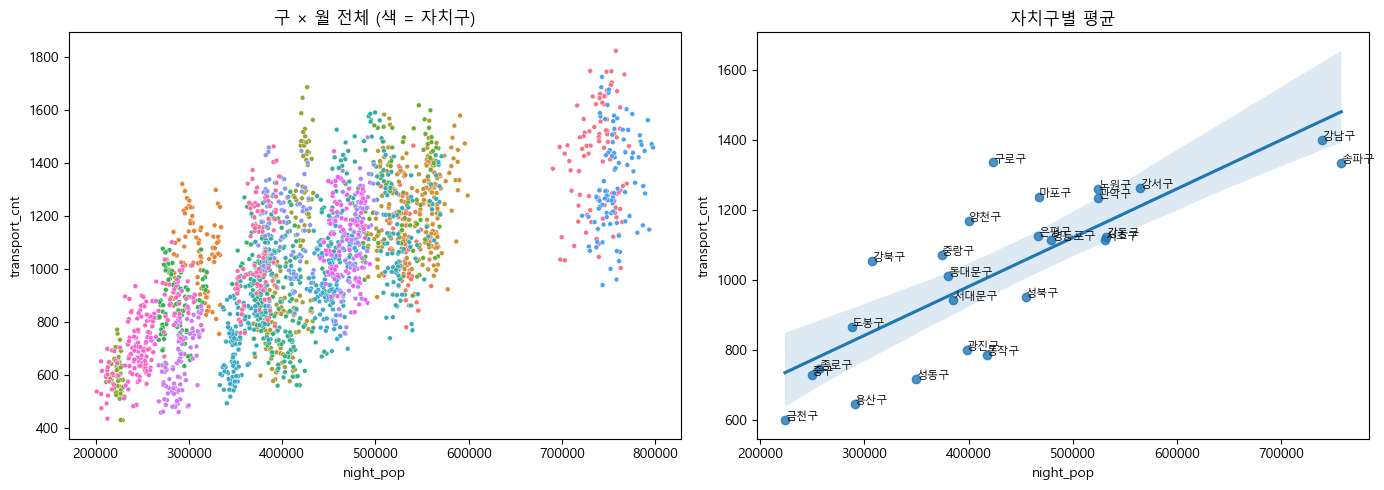

In [5]:
district_mean = df.groupby('District')[POP_COLS + ['transport_cnt']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='night_pop', y='transport_cnt', hue='District', legend=False, s=12, ax=axes[0])
axes[0].set_title('구 × 월 전체 (색 = 자치구)')

sns.regplot(data=district_mean, x='night_pop', y='transport_cnt', ax=axes[1])
for gu, row in district_mean.iterrows():
    axes[1].text(row['night_pop'], row['transport_cnt'], gu, fontsize=8)
axes[1].set_title('자치구별 평균')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_scatter.png', bbox_inches='tight')
plt.show()

## 4. 상관 분석 (4가지 관점)
- 전체 (피어슨) : 그대로 계산 → 구 규모 차이가 섞임
- 전체 (스피어만) : 순위 기반 → 이상치·비선형에 덜 민감
- 자치구 간 : 구별 평균끼리 계산 (n=25) → "큰 구가 이송도 많은가"
- 자치구 내 : 각 값에서 그 구의 평균을 뺀 뒤 계산 → "인구가 평소보다 많은 달에 이송도 많은가"
- 자치구 내 (계절 제거) : 구·월(1~12월) 평균을 뺀 뒤 계산 → 계절 효과까지 제외

In [6]:
# 자치구 내 : 구 평균 빼기
within = df.copy()
within_season = df.copy()
for c in POP_COLS + ['transport_cnt']:
    within[c] = df[c] - df.groupby('District')[c].transform('mean')
    within_season[c] = df[c] - df.groupby(['District', '월'])[c].transform('mean')

corr_table = pd.DataFrame({
    '전체_피어슨': df[POP_COLS].corrwith(df['transport_cnt']),
    '전체_스피어만': df[POP_COLS].corrwith(df['transport_cnt'], method='spearman'),
    '자치구간': district_mean[POP_COLS].corrwith(district_mean['transport_cnt']),
    '자치구내': within[POP_COLS].corrwith(within['transport_cnt']),
    '자치구내_계절제거': within_season[POP_COLS].corrwith(within_season['transport_cnt']),
}).round(3)

corr_table = corr_table.sort_values('자치구간', ascending=False)
corr_table

,전체_피어슨,전체_스피어만,자치구간,자치구내,자치구내_계절제거
night_pop,0.695,0.706,0.807,0.280,0.360
동일자치구행정동간이동인구수,0.659,0.677,0.789,0.087,0.104
일최소인구수,0.658,0.675,0.774,0.178,0.262
내국인생활인구수,0.659,0.691,0.764,0.247,0.330
total_pop,0.649,0.669,0.751,0.280,0.363
일최대인구수,0.595,0.624,0.681,0.329,0.403
day_pop,0.549,0.572,0.635,0.265,0.347
일최대이동인구수,0.404,0.334,0.453,0.294,0.365
서울외유입인구수,0.332,0.194,0.361,0.300,0.386
자치구간이동인구수,0.134,-0.013,0.140,0.313,0.387


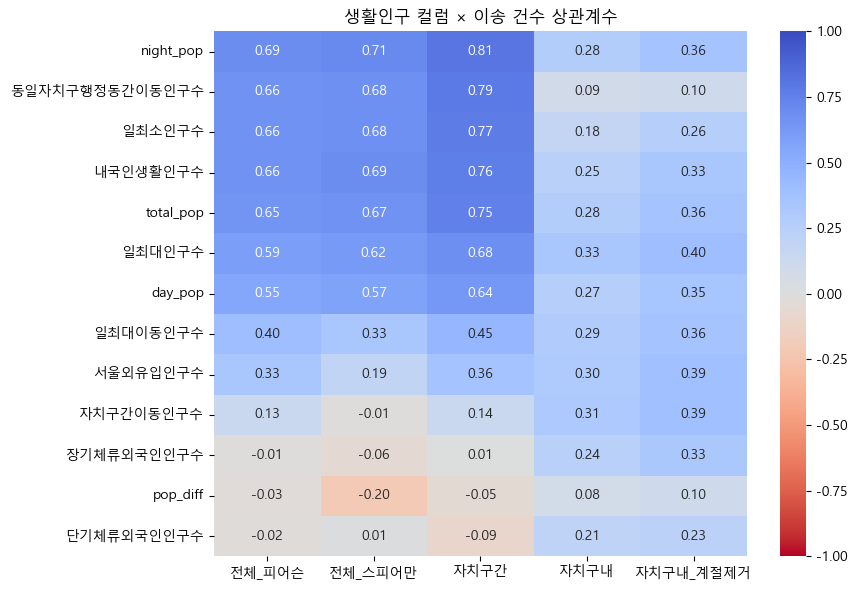

In [7]:
plt.figure(figsize=(9, 6))
sns.heatmap(corr_table, annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='coolwarm_r')
plt.title('생활인구 컬럼 × 이송 건수 상관계수')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_corr_heatmap.png', bbox_inches='tight')
plt.show()

### 4-1. 대표 인구 컬럼 선택 + 유의성 검정
- 대표 컬럼 : 자치구 간 상관이 가장 높은 컬럼
- `pearsonr` : 상관계수와 p-value를 함께 반환
- p-value ≤ 0.05 : "상관이 0이다"라는 가설 기각 → 통계적으로 의미 있음

In [8]:
KEY_POP = corr_table['자치구간'].idxmax()
print('대표 인구 컬럼 :', KEY_POP)
print()

tests = {
    '전체': (df[KEY_POP], df['transport_cnt']),
    '자치구간': (district_mean[KEY_POP], district_mean['transport_cnt']),
    '자치구내': (within[KEY_POP], within['transport_cnt']),
    '자치구내_계절제거': (within_season[KEY_POP], within_season['transport_cnt']),
}
for name, (x, y) in tests.items():
    r, p = pearsonr(x, y)
    print(f'{name:10s} r = {r:6.3f}, p-value = {p:.4f}, n = {len(x)}')

print()
print('[주간 vs 야간 인구, 자치구 간 상관]')
print(corr_table.loc[['day_pop', 'night_pop'], '자치구간'].to_string())

대표 인구 컬럼 : night_pop

전체         r =  0.695, p-value = 0.0000, n = 2233
자치구간       r =  0.807, p-value = 0.0000, n = 25
자치구내       r =  0.280, p-value = 0.0000, n = 2233
자치구내_계절제거  r =  0.360, p-value = 0.0000, n = 2233

[주간 vs 야간 인구, 자치구 간 상관]
day_pop      0.635
night_pop    0.807


## 5. 인구 1만명당 이송률
- 계산 : 구별 월평균 이송 건수 ÷ 대표 인구 × 10,000
- 의미 : 인구가 같아도 이송이 얼마나 다른지
- 이송률 차이가 크면 → 인구만으로는 부족, 구마다 다른 "이송률" 정보가 필요

이송률 최고/최저 비율 : 1.95배


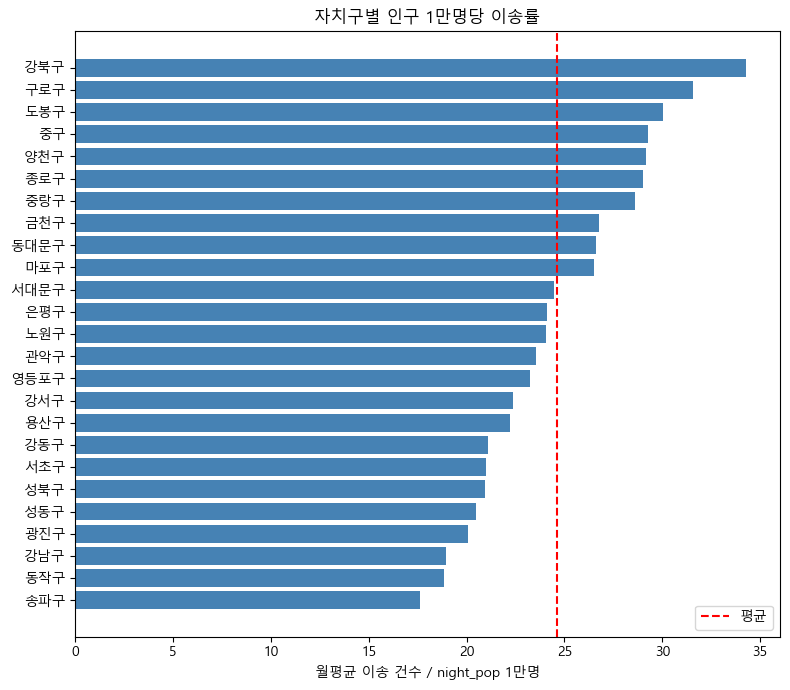

In [9]:
district_rate = pd.DataFrame({
    '월평균_이송건수': district_mean['transport_cnt'],
    '월평균_인구': district_mean[KEY_POP],
})
district_rate['인구1만명당_이송률'] = district_rate['월평균_이송건수'] / district_rate['월평균_인구'] * 10000
district_rate = district_rate.sort_values('인구1만명당_이송률')

top, bottom = district_rate['인구1만명당_이송률'].max(), district_rate['인구1만명당_이송률'].min()
print(f'이송률 최고/최저 비율 : {top / bottom:.2f}배')

plt.figure(figsize=(8, 7))
plt.barh(district_rate.index, district_rate['인구1만명당_이송률'], color='steelblue')
plt.axvline(district_rate['인구1만명당_이송률'].mean(), c='r', linestyle='--', label='평균')
plt.xlabel(f'월평균 이송 건수 / {KEY_POP} 1만명')
plt.title('자치구별 인구 1만명당 이송률')
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_district_rate.png', bbox_inches='tight')
plt.show()

## 6. 시계열 분해로 나눠 보기
- `seasonal_decompose` : 실제값 = 추세(trend) + 계절성(seasonal) + 잔차(resid)
- `period=12` : 12개월 주기, `model='additive'` : 덧셈 모델
- 구별로 이송 건수와 인구를 각각 분해 → 같은 성분끼리 상관 계산
  - 추세 상관 : 장기적으로 같이 오르내리는가
  - 계절 상관 : 계절 패턴이 같은 방향인가 (음수면 반대 방향)
  - 잔차 상관 : 갑작스러운 변화가 같이 나타나는가
- 준비 조건 : 날짜 인덱스 + 빈 달 없이 연속 (`asfreq('MS')`, 빈 달은 보간)

[25개 구 평균]
원본_상관    0.27
추세_상관    0.35
계절_상관   -0.38
잔차_상관    0.15


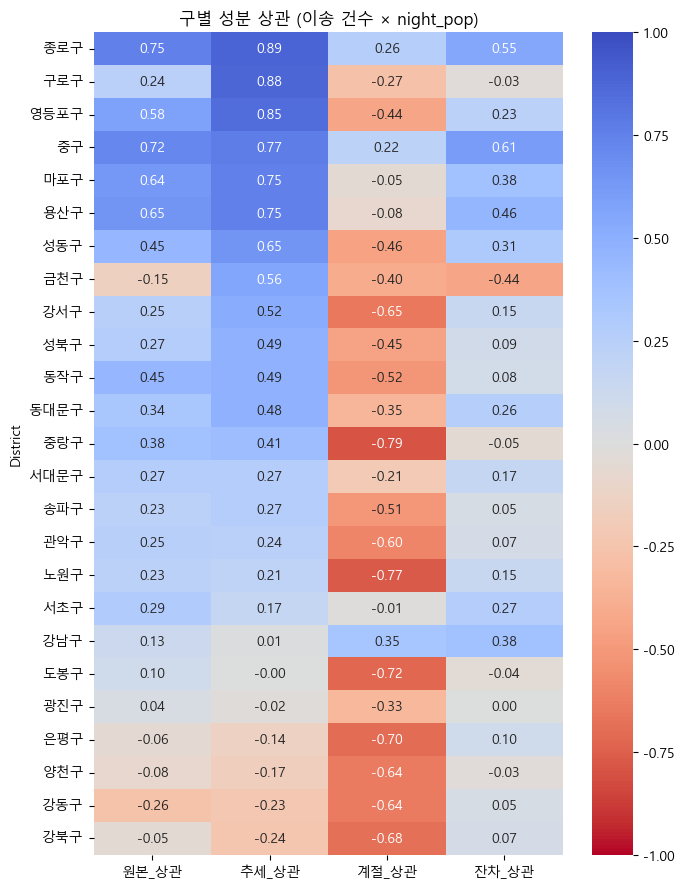

In [10]:
decomp_rows = []
decomp_result = {}

for gu, g in df.groupby('District'):
    s = g.set_index('ds')[['transport_cnt', KEY_POP]].asfreq('MS').interpolate()
    rt = seasonal_decompose(s['transport_cnt'], period=12, model='additive')
    rp = seasonal_decompose(s[KEY_POP], period=12, model='additive')
    decomp_result[gu] = (rt, rp)
    decomp_rows.append({
        'District': gu,
        '원본_상관': s['transport_cnt'].corr(s[KEY_POP]),
        '추세_상관': rt.trend.corr(rp.trend),
        '계절_상관': rt.seasonal.corr(rp.seasonal),
        '잔차_상관': rt.resid.corr(rp.resid),
    })

decomp_corr = pd.DataFrame(decomp_rows).set_index('District').round(2)
decomp_corr = decomp_corr.sort_values('추세_상관', ascending=False)

print('[25개 구 평균]')
print(decomp_corr.mean().round(2).to_string())

plt.figure(figsize=(7, 9))
sns.heatmap(decomp_corr, annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='coolwarm_r')
plt.title(f'구별 성분 상관 (이송 건수 × {KEY_POP})')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_decompose_corr.png', bbox_inches='tight')
plt.show()

### 6-1. 추세 비교 그래프 (추세 상관 최고 구 vs 최저 구)
- 단위가 달라서 표준화 후 비교 : (값 - 평균) / 표준편차
- 선이 겹칠수록 장기 흐름이 비슷함

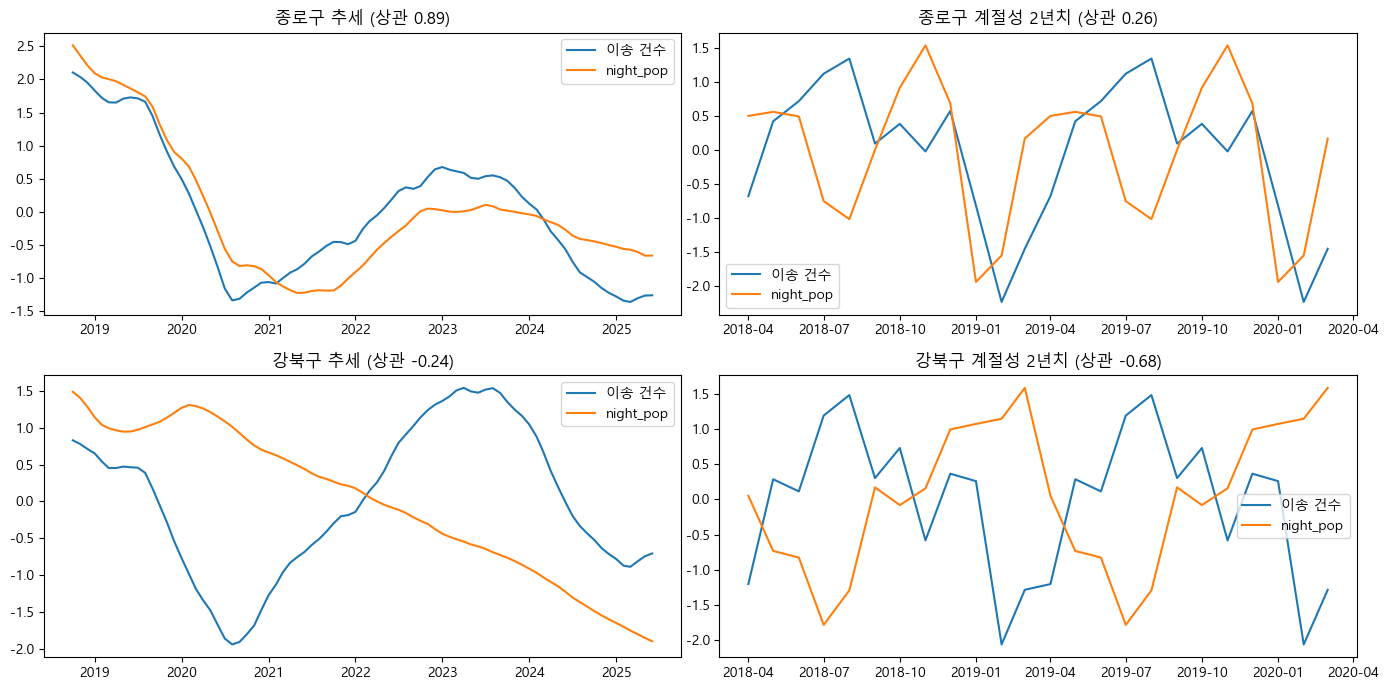

In [11]:
def zscore(s):
    return (s - s.mean()) / s.std()

pick = [decomp_corr.index[0], decomp_corr.index[-1]]
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for i, gu in enumerate(pick):
    rt, rp = decomp_result[gu]
    axes[i, 0].plot(zscore(rt.trend), label='이송 건수')
    axes[i, 0].plot(zscore(rp.trend), label=KEY_POP)
    axes[i, 0].set_title(f'{gu} 추세 (상관 {decomp_corr.loc[gu, "추세_상관"]:.2f})')
    axes[i, 0].legend()
    axes[i, 1].plot(zscore(rt.seasonal)[:24], label='이송 건수')
    axes[i, 1].plot(zscore(rp.seasonal)[:24], label=KEY_POP)
    axes[i, 1].set_title(f'{gu} 계절성 2년치 (상관 {decomp_corr.loc[gu, "계절_상관"]:.2f})')
    axes[i, 1].legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_trend_compare.png', bbox_inches='tight')
plt.show()

### 6-2. 연도별 서울 전체 흐름
- 25개 구 합계를 연도별 평균으로 비교
- 볼 것 : 인구 변화 없이 이송만 크게 변한 해가 있는지

In [12]:
city = df.groupby('ds')[['transport_cnt', KEY_POP]].sum()
yearly = city.groupby(city.index.year).mean()
yearly_change = (yearly.pct_change() * 100).round(1)
yearly_change.columns = ['이송_증감률(%)', '인구_증감률(%)']
pd.concat([yearly.round(0), yearly_change], axis=1)

,transport_cnt,night_pop,이송_증감률(%),인구_증감률(%)
ds,,,,
2018,27430.0,10687556.0,NaN,NaN
2019,26035.0,10469265.0,-5.1,-2.0
2020,20650.0,10275724.0,-20.7,-1.8
2021,21597.0,9988877.0,4.6,-2.8
2022,27143.0,10641313.0,25.7,6.5
2023,28442.0,10663715.0,4.8,0.2
2024,23686.0,10562199.0,-16.7,-1.0
2025,23062.0,10467206.0,-2.6,-0.9


## 7. 시차(lag) 확인
- 질문 : 이번 달 인구 / 1개월 전 인구 / 2개월 전 인구 중 어느 것이 이송과 더 가까운가
- 방법 : 자치구 내 값(구 평균 뺀 값)에서 인구를 `shift`로 밀어서 상관 계산
- 예측 모델에서는 미래 인구를 모르므로 보통 **전월 인구**를 사용

In [13]:
lag_rows = []
for lag in [0, 1, 2, 3]:
    temp = within_season.copy()
    temp['pop_lag'] = temp.groupby('District')[KEY_POP].shift(lag)
    temp = temp.dropna(subset=['pop_lag'])
    lag_rows.append({'시차(개월)': lag, '상관계수': round(temp['pop_lag'].corr(temp['transport_cnt']), 3)})

lag_table = pd.DataFrame(lag_rows)
lag_table

,시차(개월),상관계수
0,0,0.360
1,1,0.320
2,2,0.282
3,3,0.236


## 8. 예측 모델로 확인하기
- 질문 : 생활인구를 넣으면 이송 건수 예측이 실제로 좋아지는가
- 데이터 분할 : 시간 순서 기준 (2025년 = 테스트)
  - `train_test_split` 무작위 분할을 쓰지 않는 이유 : 미래 데이터가 학습에 섞이는 것 방지
- 인구 특성은 모두 **전월 값** 사용 → 실제 예측 시점에 알 수 있는 값

**새로 만드는 특성**
- `구코드` : `LabelEncoder`로 자치구 이름 → 숫자
- `구별_이송률` : 학습 기간만으로 계산한 "이송 건수 ÷ 전월 인구" 구별 평균 (타깃 인코딩과 같은 원리)
- `인구기반_예상` : 구별_이송률 × 전월 인구 → "인구로 본 기대 이송 건수"

In [14]:
data = transport.copy()
data['구코드'] = LabelEncoder().fit_transform(data['District'])

POP_KEY_PREV = '전월_' + KEY_POP
train_part = data[data['ds'] < TEST_START]
rate_map = (train_part['transport_cnt'] / train_part[POP_KEY_PREV]).groupby(train_part['District']).mean()

data['구별_이송률'] = data['District'].map(rate_map)
data['인구기반_예상'] = data['구별_이송률'] * data[POP_KEY_PREV]

print('구별 이송률 (학습 기간, 상위 5개)')
print((rate_map * 10000).sort_values(ascending=False).head().round(1).to_string())

구별 이송률 (학습 기간, 상위 5개)
District
강북구    34.3
구로구    32.6
도봉구    30.2
중구     29.4
종로구    29.4


### 8-1. 특성 조합 5가지
- A 계절 : 월, 구코드
- B 계절+인구 : A + 전월 생활인구 4종
- C 계절+인구+이송률 : B + 인구기반_예상
- D 계절+이송이력 : A + 전월 이송 건수, 전년 동월 이송 건수
- E 전체 : D + 전월 생활인구 4종 + 인구기반_예상

**비교 포인트**
- A → B → C : 과거 이송 기록이 없을 때 인구가 주는 효과
- D → E : 과거 이송 기록이 있을 때 인구가 추가로 주는 효과

In [15]:
POP_FEATURES = ['전월_night_pop', '전월_day_pop', '전월_일최대인구수', '전월_서울외유입인구수']
BASE = ['월', '구코드']
HISTORY = ['전월_transport_cnt', '전년동월_transport_cnt']

FEATURE_SETS = {
    'A_계절': BASE,
    'B_계절+인구': BASE + POP_FEATURES,
    'C_계절+인구+이송률': BASE + POP_FEATURES + ['인구기반_예상'],
    'D_계절+이송이력': BASE + HISTORY,
    'E_전체': BASE + HISTORY + POP_FEATURES + ['인구기반_예상'],
}

# 모든 조합이 같은 행으로 비교되도록 결측 행 제거
all_features = sorted(set(sum(FEATURE_SETS.values(), [])))
model_df = data.dropna(subset=all_features + ['transport_cnt'])

train = model_df[model_df['ds'] < TEST_START]
test = model_df[model_df['ds'] >= TEST_START]
print('학습 :', train.shape, train['ds'].min().date(), '~', train['ds'].max().date())
print('테스트 :', test.shape, test['ds'].min().date(), '~', test['ds'].max().date())

학습 : (1880, 49) 2018-05-01 ~ 2024-12-01
테스트 : (300, 49) 2025-01-01 ~ 2025-12-01


### 8-2. 학습 및 평가
- 모델 : `LinearRegression`(직선 관계), `RandomForestRegressor`(트리 여러 개의 평균)
- 평가 지표
  - R² : 1에 가까울수록 좋음
  - MAE : 평균 오차 (건)
  - 정확도 : 100 - MAPE(%)
- 기준선(naive) : "이번 달 = 지난달" 그대로 쓴 예측

In [16]:
def evaluate(y_true, y_pred):
    return {
        'R2': round(r2_score(y_true, y_pred), 3),
        'MAE': round(mean_absolute_error(y_true, y_pred), 1),
        '정확도(%)': round(100 - mean_absolute_percentage_error(y_true, y_pred) * 100, 2),
    }

results = []
rf_models = {}
for set_name, features in FEATURE_SETS.items():
    models = {
        'LinearRegression': LinearRegression(),
        'RandomForest': RandomForestRegressor(n_estimators=300, random_state=10, n_jobs=-1),
    }
    for model_name, model in models.items():
        model.fit(train[features], train['transport_cnt'])
        pred = model.predict(test[features])
        results.append({'특성조합': set_name, '모델': model_name, **evaluate(test['transport_cnt'], pred)})
        if model_name == 'RandomForest':
            rf_models[set_name] = model

results.append({'특성조합': '기준선(전월값)', '모델': '-', **evaluate(test['transport_cnt'], test['전월_transport_cnt'])})
compare = pd.DataFrame(results)
compare

,특성조합,모델,R2,MAE,정확도(%)
0,A_계절,LinearRegression,-0.140,188.7,74.17
1,A_계절,RandomForest,0.625,117.1,86.70
2,B_계절+인구,LinearRegression,0.378,150.2,81.42
3,B_계절+인구,RandomForest,0.698,100.8,88.36
4,C_계절+인구+이송률,LinearRegression,0.677,106.5,87.74
5,C_계절+인구+이송률,RandomForest,0.750,89.8,89.57
6,D_계절+이송이력,LinearRegression,0.918,48.3,94.59
7,D_계절+이송이력,RandomForest,0.928,47.5,94.67
8,E_전체,LinearRegression,0.923,45.9,94.82
9,E_전체,RandomForest,0.928,47.6,94.68


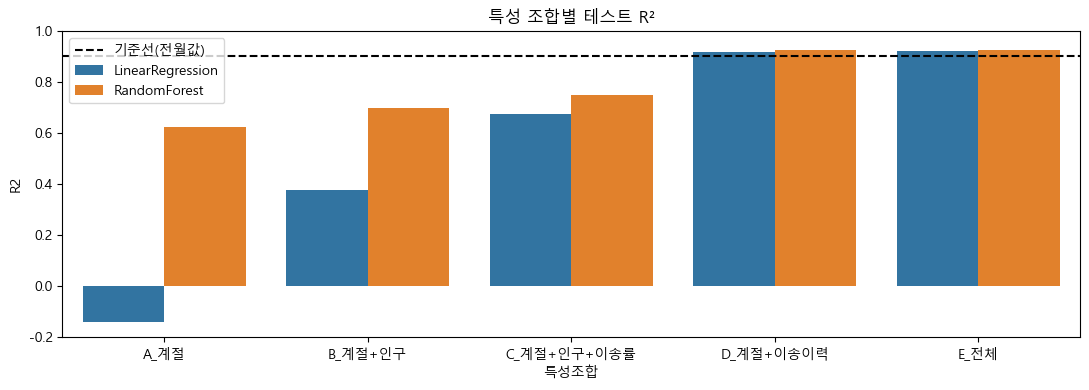

In [17]:
plot_df = compare[compare['모델'] != '-']
plt.figure(figsize=(11, 4))
sns.barplot(data=plot_df, x='특성조합', y='R2', hue='모델')
plt.axhline(compare.iloc[-1]['R2'], c='k', linestyle='--', label='기준선(전월값)')
plt.ylim(-0.2, 1)
plt.title('특성 조합별 테스트 R²')
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_model_compare.png', bbox_inches='tight')
plt.show()

### 8-3. 특성 중요도 (RandomForest)
- `feature_importances_` : 예측에 많이 쓰인 특성일수록 큰 값 (합계 1)
- C : 이송 기록 없이 인구만 있을 때 무엇이 중요한가
- E : 이송 기록과 인구를 함께 넣었을 때 무엇이 중요한가

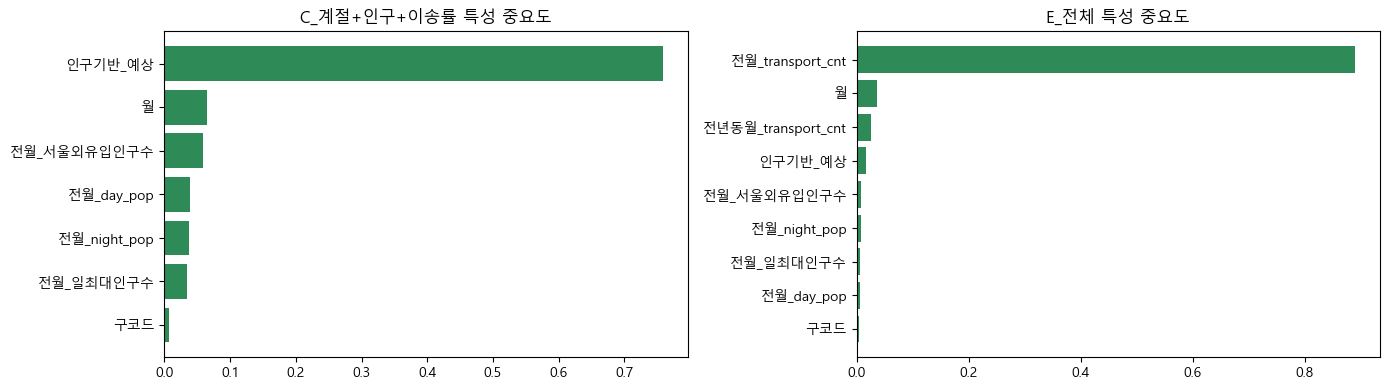

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, set_name in zip(axes, ['C_계절+인구+이송률', 'E_전체']):
    imp = pd.Series(rf_models[set_name].feature_importances_, index=FEATURE_SETS[set_name]).sort_values()
    ax.barh(imp.index, imp.values, color='seagreen')
    ax.set_title(f'{set_name} 특성 중요도')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'relation_feature_importance.png', bbox_inches='tight')
plt.show()

## 9. 결과 저장
- 분석 표 3개 → `ml_result`
- 인구 기반 특성(`구별_이송률`, `인구기반_예상`)을 붙인 학습 데이터 → `ml_data/transport_pop_features.csv`
  - 이송률은 2024년까지 데이터로만 계산 (테스트 기간 정보 누수 방지)

In [19]:
corr_table.to_csv(RESULT_DIR / 'relation_corr_table.csv', encoding='utf-8-sig')

district_out = district_rate.join(decomp_corr).reset_index().rename(columns={'District': '지역구명'})
district_out.round(3).to_csv(RESULT_DIR / 'relation_district_rate.csv', index=False, encoding='utf-8-sig')

compare.to_csv(RESULT_DIR / 'relation_model_compare.csv', index=False, encoding='utf-8-sig')

save_cols = transport.columns.drop('transport_cnt').tolist() + ['구별_이송률', '인구기반_예상', 'transport_cnt']
data[save_cols].to_csv(ML_DATA_DIR / 'transport_pop_features.csv', index=False, encoding='utf-8-sig')

print('저장 완료')
for f in ['relation_corr_table.csv', 'relation_district_rate.csv', 'relation_model_compare.csv']:
    print(' -', RESULT_DIR / f)
print(' -', ML_DATA_DIR / 'transport_pop_features.csv')

저장 완료
 - C:\ai\source\09_Project\cheolhyeon_jo\ml_result\relation_corr_table.csv
 - C:\ai\source\09_Project\cheolhyeon_jo\ml_result\relation_district_rate.csv
 - C:\ai\source\09_Project\cheolhyeon_jo\ml_result\relation_model_compare.csv
 - C:\ai\source\09_Project\cheolhyeon_jo\ml_data\transport_pop_features.csv


## 10. 결과 요약 (자동 출력)
- 숫자는 실행 결과에서 바로 가져옴 → 데이터가 바뀌어도 그대로 사용 가능

In [20]:
c = corr_table.loc[KEY_POP]
get = lambda s, m: compare[(compare['특성조합'] == s) & (compare['모델'] == m)].iloc[0]

print(f'[대표 인구] {KEY_POP}')
print(f'1) 자치구 간 상관 {c["자치구간"]:.2f} vs 자치구 내 상관 {c["자치구내"]:.2f}')
print('   → 인구는 "어느 구가 이송이 많은가"(규모)는 잘 설명, "어느 달에 늘어나는가"는 약하게 설명')
print(f'2) 주간인구 {corr_table.loc["day_pop", "자치구간"]:.2f} vs 야간인구 {corr_table.loc["night_pop", "자치구간"]:.2f} (자치구 간)')
print(f'3) 인구 1만명당 이송률 최고/최저 {top / bottom:.1f}배 차이 → 구별 이송률 정보 필요')
print(f'4) 계절 성분 상관 평균 {decomp_corr["계절_상관"].mean():.2f} → 계절성은 인구가 아닌 별도 특성(월)으로 반영')
print(f'5) 추세 성분 상관 평균 {decomp_corr["추세_상관"].mean():.2f} (구별 편차 큼)')
for m in ['LinearRegression', 'RandomForest']:
    a, b_, c_ = get('A_계절', m)['R2'], get('B_계절+인구', m)['R2'], get('C_계절+인구+이송률', m)['R2']
    d, e = get('D_계절+이송이력', m)['R2'], get('E_전체', m)['R2']
    print(f'6) {m:16s} 이송기록 없음 A {a:.3f} → B {b_:.3f} → C {c_:.3f} | 이송기록 있음 D {d:.3f} → E {e:.3f}')

[대표 인구] night_pop
1) 자치구 간 상관 0.81 vs 자치구 내 상관 0.28
   → 인구는 "어느 구가 이송이 많은가"(규모)는 잘 설명, "어느 달에 늘어나는가"는 약하게 설명
2) 주간인구 0.64 vs 야간인구 0.81 (자치구 간)
3) 인구 1만명당 이송률 최고/최저 1.9배 차이 → 구별 이송률 정보 필요
4) 계절 성분 상관 평균 -0.38 → 계절성은 인구가 아닌 별도 특성(월)으로 반영
5) 추세 성분 상관 평균 0.35 (구별 편차 큼)
6) LinearRegression 이송기록 없음 A -0.140 → B 0.378 → C 0.677 | 이송기록 있음 D 0.918 → E 0.923
6) RandomForest     이송기록 없음 A 0.625 → B 0.698 → C 0.750 | 이송기록 있음 D 0.928 → E 0.928


## 11. 해석 가이드
- 규모 설명 변수 : 생활인구 (특히 야간인구) → 구별 이송 건수 수준 결정
- 월별 변동 설명 변수 : 계절(월), 전월·전년 동월 이송 건수 → 인구보다 영향 큼
- 이송률 차이 : 같은 인구라도 구마다 이송 발생 비율이 다름 → 인구 × 구별 이송률 조합이 효과적
- 인구 특성이 유용한 상황
  - 과거 이송 기록이 없거나 부족할 때
  - 여러 달 앞을 예측할 때 (전월 이송 값도 예측값이라 오차가 쌓임)
  - 인구 변화 시나리오 분석 (인구 예측 모델 결과 연결)
- 인구 특성의 한계 : 전월 이송 건수가 이미 구 규모 정보를 담고 있어서 추가 효과가 작음